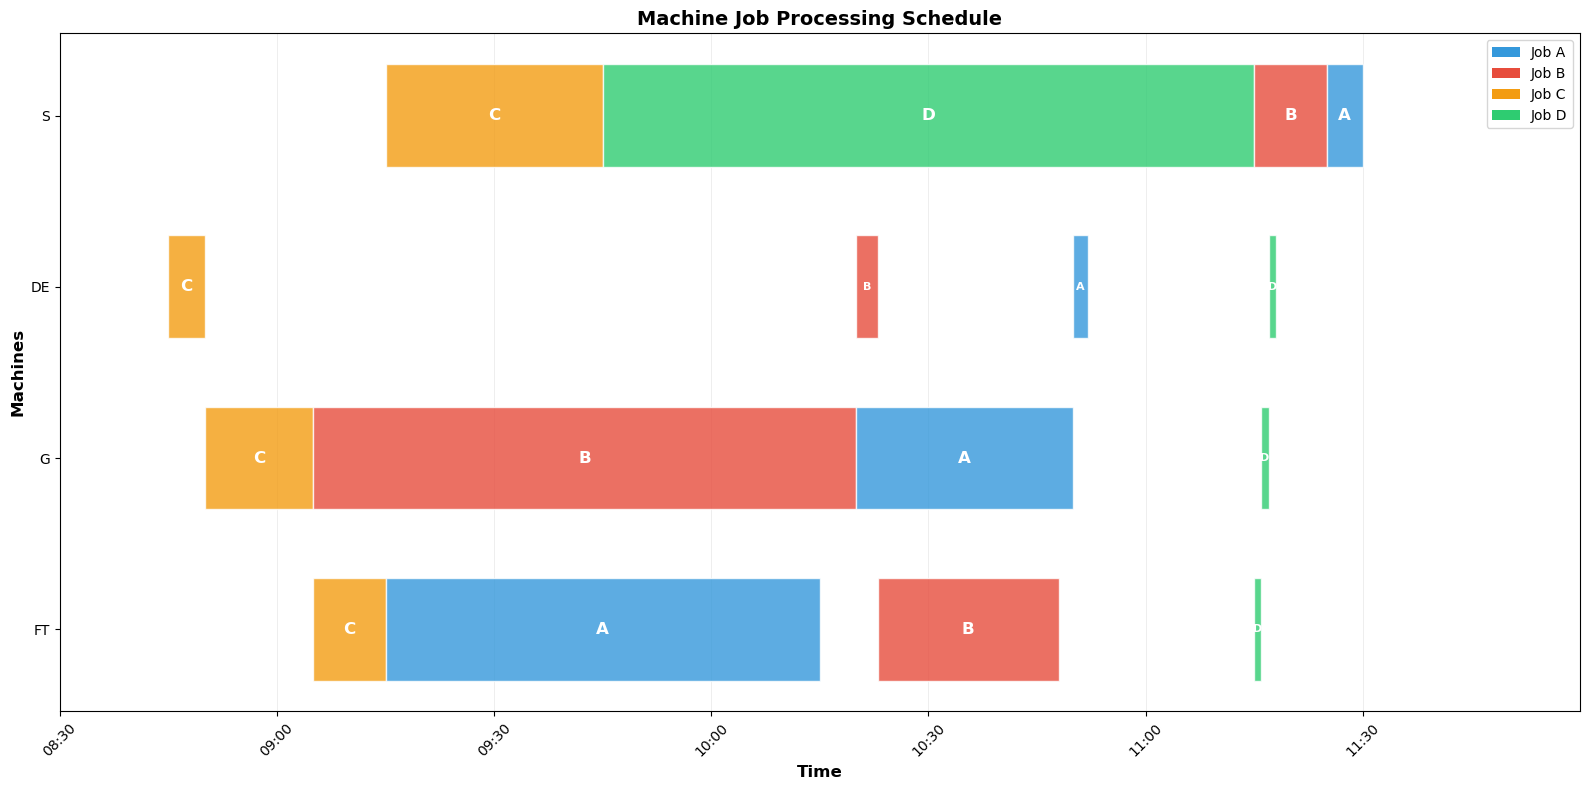

각 기계별 작업 스케줄 (실제 시작 시간 기준)

FT 기계:
Job	Start Time	Duration	End Time	Gap to Next
------------------------------------------------------------
C	09:05		10분		09:15	
A	09:15		60분		10:15	(연속)
B	10:23		25분		10:47	(+8분 간격)
D	11:15		1분		11:16	(+27분 간격)

G 기계:
Job	Start Time	Duration	End Time	Gap to Next
------------------------------------------------------------
C	08:50		15분		09:05	
B	09:05		75분		10:20	(연속)
A	10:20		30분		10:50	(연속)
D	11:16		1분		11:17	(+26분 간격)

DE 기계:
Job	Start Time	Duration	End Time	Gap to Next
------------------------------------------------------------
C	08:45		5분		08:50	
B	10:20		3분		10:23	(+90분 간격)
A	10:50		2분		10:52	(+27분 간격)
D	11:17		1분		11:18	(+25분 간격)

S 기계:
Job	Start Time	Duration	End Time	Gap to Next
------------------------------------------------------------
C	09:15		30분		09:45	
D	09:45		90분		11:15	(연속)
B	11:15		10분		11:24	(연속)
A	11:25		5분		11:30	(연속)


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 원본 데이터 (실제 시작 시간 사용)
data = {
    'Machine': ['FT', 'FT', 'FT', 'FT', 'G', 'G', 'G', 'G', 'DE', 'DE', 'DE', 'DE', 'S', 'S', 'S', 'S'],
    'Job': ['A', 'B', 'C', 'D', 'A', 'B', 'C', 'D', 'A', 'B', 'C', 'D', 'A', 'B', 'C', 'D'],
    'Start_time': ['09:15', '10:23', '09:05', '11:15', '10:20', '09:05', '08:50', '11:16', 
                   '10:50', '10:20', '08:45', '11:17', '11:25', '11:15', '09:15', '09:45'],
    'Duration_minutes': [60, 25, 10, 1, 30, 75, 15, 1, 2, 3, 5, 1, 5, 10, 30, 90]
}

df = pd.DataFrame(data)

def time_to_decimal(time_str):
    """시간 문자열을 소수점으로 변환"""
    hours, minutes = map(int, time_str.split(':'))
    return hours + minutes / 60

def decimal_to_time(decimal_hour):
    """소수점 시간을 HH:MM 형식으로 변환"""
    hours = int(decimal_hour)
    minutes = int((decimal_hour - hours) * 60)
    return f"{hours:02d}:{minutes:02d}"

# 시간 변환
df['Start_decimal'] = df['Start_time'].apply(time_to_decimal)
df['Duration_hours'] = df['Duration_minutes'] / 60
df['End_decimal'] = df['Start_decimal'] + df['Duration_hours']

# 각 기계별로 작업을 시간 순서대로 정렬
df_sorted = df.sort_values(['Machine', 'Start_decimal']).reset_index(drop=True)

# 간트차트 그리기
fig, ax = plt.subplots(figsize=(16, 8))

# Job별 색상 설정
colors = {'A': '#3498db', 'B': '#e74c3c', 'C': '#f39c12', 'D': '#2ecc71'}

# 기계 순서 (원본과 동일하게)
machines = ['FT', 'G', 'DE', 'S']
y_positions = {machine: i for i, machine in enumerate(machines)}

# 각 작업을 막대로 그리기
for _, row in df_sorted.iterrows():
    machine = row['Machine']
    job = row['Job']
    start = row['Start_decimal']
    duration = row['Duration_hours']
    
    y_pos = y_positions[machine]
    
    # 작업 막대 그리기
    ax.barh(y_pos, duration, left=start, height=0.6, 
            color=colors[job], alpha=0.8, edgecolor='white', linewidth=1)
    
    # Job 이름 표시
    if duration > 0.05:  # 3분 이상일 때만 텍스트 표시
        ax.text(start + duration/2, y_pos, job, 
                ha='center', va='center', fontweight='bold', 
                fontsize=12, color='white')
    elif duration > 0.01:  # 매우 짧은 작업도 작은 글씨로 표시
        ax.text(start + duration/2, y_pos, job, 
                ha='center', va='center', fontweight='bold', 
                fontsize=8, color='white')

# 차트 설정
ax.set_yticks(range(len(machines)))
ax.set_yticklabels(machines)
ax.set_ylabel('Machines', fontsize=12, fontweight='bold')
ax.set_xlabel('Time', fontsize=12, fontweight='bold')
ax.set_title('Machine Job Processing Schedule', fontsize=14, fontweight='bold')

# X축 설정 (8시부터 13시까지)
ax.set_xlim(8.5, 12)

# X축 시간 눈금 설정 (30분 간격)
ticks = np.arange(8.5, 12, 0.5)
ax.set_xticks(ticks)
ax.set_xticklabels([decimal_to_time(t) for t in ticks], rotation=45)

# 격자 추가
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, axis='x')
ax.set_axisbelow(True)

# 범례 추가
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[job], label=f'Job {job}') for job in ['A', 'B', 'C', 'D']]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# 각 기계별 작업 스케줄 분석
print("=" * 80)
print("각 기계별 작업 스케줄 (실제 시작 시간 기준)")
print("=" * 80)

for machine in machines:
    machine_data = df_sorted[df_sorted['Machine'] == machine].sort_values('Start_decimal')
    print(f"\n{machine} 기계:")
    print("Job\tStart Time\tDuration\tEnd Time\tGap to Next")
    print("-" * 60)
    
    prev_end = None
    for i, (_, row) in enumerate(machine_data.iterrows()):
        start_time = row['Start_time']
        end_decimal = row['End_decimal']
        end_time = decimal_to_time(end_decimal)
        duration_min = row['Duration_minutes']
        
        # 이전 작업과의 간격 계산
        gap = ""
        if prev_end is not None:
            gap_hours = row['Start_decimal'] - prev_end
            gap_minutes = gap_hours * 60
            if gap_minutes > 0:
                gap = f"(+{gap_minutes:.0f}분 간격)"
            elif gap_minutes < 0:
                gap = f"({-gap_minutes:.0f}분 겹침!)"
            else:
                gap = "(연속)"
        
        print(f"{row['Job']}\t{start_time}\t\t{duration_min}분\t\t{end_time}\t{gap}")
        prev_end = end_decimal

In [13]:
import random

# --- 문제 데이터 정의 ---
# 작업별 가공 시간 (모두 동일)
PROCESSING_TIME = 5
NUM_JOBS = 4

# 작업 준비 시간 행렬 (s[i][j]는 (i+1) -> (j+1) 작업의 준비 시간)
SETUP_TIMES = [
    # J1, J2, J3, J4 (To)
    [0,  3,  5,  9],  # J1 (From)
    [4,  0,  2,  8],  # J2 (From)
    [3,  3,  0,  6],  # J3 (From)
    [2,  7,  1,  0]   # J4 (From)
]

# --- 핵심 기능 함수 ---

def calculate_makespan(sequence):
    """주어진 작업 순서(sequence)에 대한 Makespan을 계산합니다."""
    total_processing_time = NUM_JOBS * PROCESSING_TIME
    total_setup_time = 0
    for i in range(len(sequence) - 1):
        preceding_job_idx = sequence[i] - 1
        following_job_idx = sequence[i+1] - 1
        total_setup_time += SETUP_TIMES[preceding_job_idx][following_job_idx]
    return total_processing_time + total_setup_time

def get_sapi_neighbors(sequence):
    """SAPI(인접한 두 작업 교환) 방식으로 이웃 해 목록을 생성합니다."""
    neighbors = []
    for i in range(len(sequence) - 1):
        neighbor = sequence[:]
        neighbor[i], neighbor[i+1] = neighbor[i+1], neighbor[i]
        neighbors.append(neighbor)
    return neighbors

def get_spi_neighbors(sequence):
    """SPI(모든 두 작업 교환) 방식으로 이웃 해 목록을 생성합니다."""
    neighbors = []
    for i in range(len(sequence)):
        for j in range(i + 1, len(sequence)):
            neighbor = sequence[:]
            neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
            neighbors.append(neighbor)
    return neighbors

def run_simulation(initial_sequence, neighbor_func, selection_strategy, max_iterations):
    """하나의 탐색 알고리즘 시뮬레이션을 실행하고 과정을 상세히 출력합니다."""
    
    current_sequence = initial_sequence[:]
    current_makespan = calculate_makespan(current_sequence)
    
    print(f"초기 해: {current_sequence}, Makespan: {current_makespan}")
    
    for i in range(max_iterations):
        print(f"\n===== [반복 {i+1}] =====")
        print(f"현재 해: {current_sequence} (Makespan: {current_makespan})")
        
        # 1. 이웃 해 생성 및 평가
        neighbors = neighbor_func(current_sequence)
        print("  [1] 생성된 이웃 해 목록:")
        
        neighbor_details = []
        for neighbor in neighbors:
            makespan = calculate_makespan(neighbor)
            neighbor_details.append({'seq': neighbor, 'span': makespan})
            print(f"      - 순서: {neighbor}, Makespan: {makespan}")

        # 2. 이웃 해 선택
        print(f"  [2] 이웃 해 선택 ({selection_strategy}):")
        selected_neighbor_detail = None

        if selection_strategy == 'greedy':
            selected_neighbor_detail = min(neighbor_details, key=lambda x: x['span'])
            print(f"      -> 가장 좋은 해인 {selected_neighbor_detail['seq']} (Makespan: {selected_neighbor_detail['span']})을(를) 선택.")
        
        elif selection_strategy == 'random':
            selected_neighbor_detail = random.choice(neighbor_details)
            print(f"      -> 무작위로 {selected_neighbor_detail['seq']} (Makespan: {selected_neighbor_detail['span']})을(를) 선택.")

        # 3. 이동 결정
        print("  [3] 이동 결정:")
        if selected_neighbor_detail['span'] < current_makespan:
            print(f"      -> 현재 해보다 좋으므로 {selected_neighbor_detail['seq']}(으)로 이동합니다.")
            current_sequence = selected_neighbor_detail['seq']
            current_makespan = selected_neighbor_detail['span']
        else:
            print(f"      -> 현재 해보다 좋지 않으므로 이동하지 않습니다. 현재 해를 유지합니다.")
            
    print(f"\n--- 최종 결과 ---\n최종 해: {current_sequence}, Makespan: {current_makespan}\n")
    return current_sequence, current_makespan

# --- 메인 실행 부분 ---
if __name__ == "__main__":
    initial_sequence = [1, 3, 4, 2]

    print("------------------------------------------")
    print("알고리즘 1: SAPI + Greedy 시뮬레이션       ")
    print("------------------------------------------")
    run_simulation(initial_sequence, get_sapi_neighbors, 'greedy', 5)

    print("\n------------------------------------------")
    print("알고리즘 2: SAPI + Random 시뮬레이션       ")
    print("------------------------------------------")
    run_simulation(initial_sequence, get_sapi_neighbors, 'random', 5)

    print("\n------------------------------------------")
    print("알고리즘 3: SPI + Greedy 시뮬레이션        ")
    print("------------------------------------------")
    run_simulation(initial_sequence, get_spi_neighbors, 'greedy', 5)

    print("\n------------------------------------------")
    print("알고리즘 4: SPI + Random 시뮬레이션        ")
    print("------------------------------------------")
    run_simulation(initial_sequence, get_spi_neighbors, 'random', 5)

------------------------------------------
알고리즘 1: SAPI + Greedy 시뮬레이션       
------------------------------------------
초기 해: [1, 3, 4, 2], Makespan: 38

===== [반복 1] =====
현재 해: [1, 3, 4, 2] (Makespan: 38)
  [1] 생성된 이웃 해 목록:
      - 순서: [3, 1, 4, 2], Makespan: 39
      - 순서: [1, 4, 3, 2], Makespan: 33
      - 순서: [1, 3, 2, 4], Makespan: 36
  [2] 이웃 해 선택 (greedy):
      -> 가장 좋은 해인 [1, 4, 3, 2] (Makespan: 33)을(를) 선택.
  [3] 이동 결정:
      -> 현재 해보다 좋으므로 [1, 4, 3, 2](으)로 이동합니다.

===== [반복 2] =====
현재 해: [1, 4, 3, 2] (Makespan: 33)
  [1] 생성된 이웃 해 목록:
      - 순서: [4, 1, 3, 2], Makespan: 30
      - 순서: [1, 3, 4, 2], Makespan: 38
      - 순서: [1, 4, 2, 3], Makespan: 38
  [2] 이웃 해 선택 (greedy):
      -> 가장 좋은 해인 [4, 1, 3, 2] (Makespan: 30)을(를) 선택.
  [3] 이동 결정:
      -> 현재 해보다 좋으므로 [4, 1, 3, 2](으)로 이동합니다.

===== [반복 3] =====
현재 해: [4, 1, 3, 2] (Makespan: 30)
  [1] 생성된 이웃 해 목록:
      - 순서: [1, 4, 3, 2], Makespan: 33
      - 순서: [4, 3, 1, 2], Makespan: 27
      - 순서: [4, 1, 2, 3], Makespan: 27
  [2

해 선택 방식: Greedy vs Random
- Greedy Search는 언제나 가장 좋은 이웃해를 선택하기 때문에 안정적으로 성능을 개선하는 경향을 보이고, 이번 시뮬레이션 결과 두 Greedy 알고리즘 모두 최적 Makespan 27을 찾아냈다. 
- Random Search는 이웃해 선택을 랜덤하게 하므로 성능 개선이 불안정하다. 그 결과 SAPI+Random은 초기해보다 나쁜 결과를 냈고, SPI+Random은 최적해를 찾았다. 

이웃해 생성 방식: SAPI vs SPI
- SAPI는 탐색 범위가 좁아 점진적인 개선을 보인다
- SPI는 탐색 범위가 넓어 더 빠른 개선을 보인다. SPI+Greedy는 첫 iteration에 최적해를 찾았다. 

결론
- 더 넓은 범위의 탐색과 안정적인 성능 개선이 가능한 SPI + Greedy 알고리즘이 가장 robust할 것으로 예상된다. 

이웃해 생성 방식: SAPI vs SPI
- SAPI는 탐색 범위가 좁아 점진적인 개선을 보인다
- SPI는 탐색 범위가 넓어 더 빠른 개선을 보인다. SPI+Greedy는 첫 iteration에 최적해를 찾았다. 